In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare data
df = pd.read_csv("cleaned_bearing_data.csv")
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])

# Calculate operational days
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df = df[df['operational_days'].notna()]


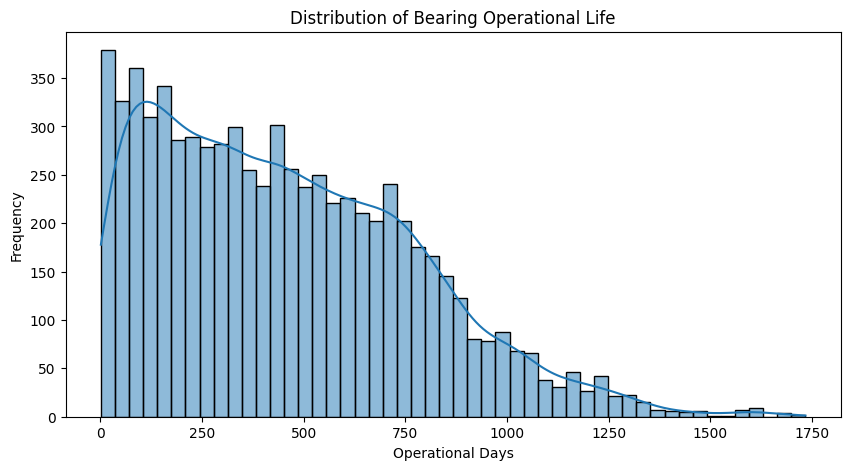

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['operational_days'], bins=50, kde=True)
plt.title("Distribution of Bearing Operational Life")
plt.xlabel("Operational Days")
plt.ylabel("Frequency")
plt.show()


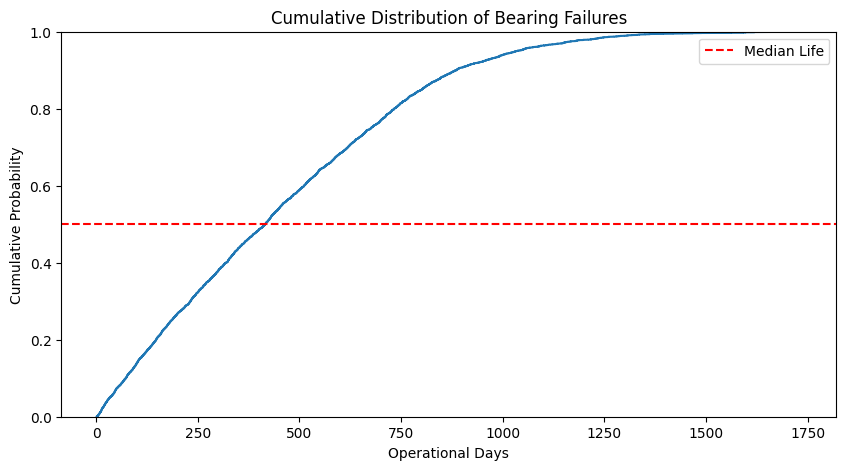

Median life: 416.0 days, 75th percentile: 677.0, 90th percentile: 886.8000000000011


In [6]:
plt.figure(figsize=(10, 5))
sns.ecdfplot(df['operational_days'])
plt.title("Cumulative Distribution of Bearing Failures")
plt.xlabel("Operational Days")
plt.ylabel("Cumulative Probability")
plt.axhline(0.5, color='red', linestyle='--', label='Median Life')
plt.legend()
plt.show()

# Find median and quantiles
median_life = df['operational_days'].median()
q75_life = df['operational_days'].quantile(0.75)
q90_life = df['operational_days'].quantile(0.9)
print(f"Median life: {median_life} days, 75th percentile: {q75_life}, 90th percentile: {q90_life}")


In [7]:
# Define bins of 500-day intervals
df['life_bin'] = pd.cut(df['operational_days'], bins=range(0, int(df['operational_days'].max()) + 500, 500))

life_bin_summary = df['life_bin'].value_counts().sort_index().reset_index()
life_bin_summary.columns = ['Life Bin', 'Failure Count']
life_bin_summary.to_csv("outputs/q5/life_bin_summary.csv", index=False)


In [8]:
# Save full operational_days column
df[['operational_days']].to_csv("outputs/q5/failure_times.csv", index=False)

# Also save quantiles
summary_stats = pd.DataFrame({
    "Metric": ["Median", "75th Percentile", "90th Percentile"],
    "Days": [median_life, q75_life, q90_life]
})
summary_stats.to_csv("outputs/q5/useful_life_summary.csv", index=False)


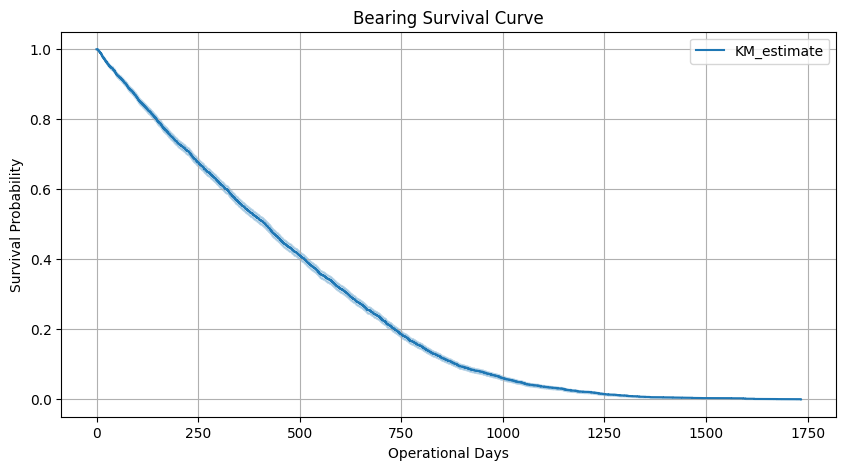

In [9]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df['operational_days'])

# Plot
plt.figure(figsize=(10, 5))
kmf.plot()
plt.title("Bearing Survival Curve")
plt.xlabel("Operational Days")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()


In [10]:
survival_df = pd.DataFrame({
    'operational_days': kmf.survival_function_.index,
    'survival_probability': kmf.survival_function_['KM_estimate']
})
survival_df.to_csv("outputs/q5/survival_curve.csv", index=False)
